## <span style="color:#db7d60">Purpose</span>

The goal of this notebook is to see if the new trainings for exp11 with suffix `rp2` reproduce the same results as the original trainings.

In [35]:
%load_ext autoreload
%autoreload 2

import sys
import time
import json
import pickle
from collections import Counter, defaultdict
from types import SimpleNamespace
from itertools import islice
from pathlib import Path
# Math
import math
import numpy as np
import pandas as pd
from numba import njit, float64, types
from numba.experimental import jitclass
from numba.typed import Dict
from scipy.signal import savgol_filter
from numerize import numerize
# Plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib.ticker import ScalarFormatter, FuncFormatter
from matplotlib.patches import FancyBboxPatch
import seaborn as sns

from particle import Particle
import vector
import jetnet
import jetnet.evaluation

# pUtil needs to be loaded from the root directory
parent_dir = Path().resolve().parent
sys.path.insert(0, str(parent_dir))

# particleGPT
import pUtil
import data_manager
from analysis_common import *
import analysis_v2 as analv2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


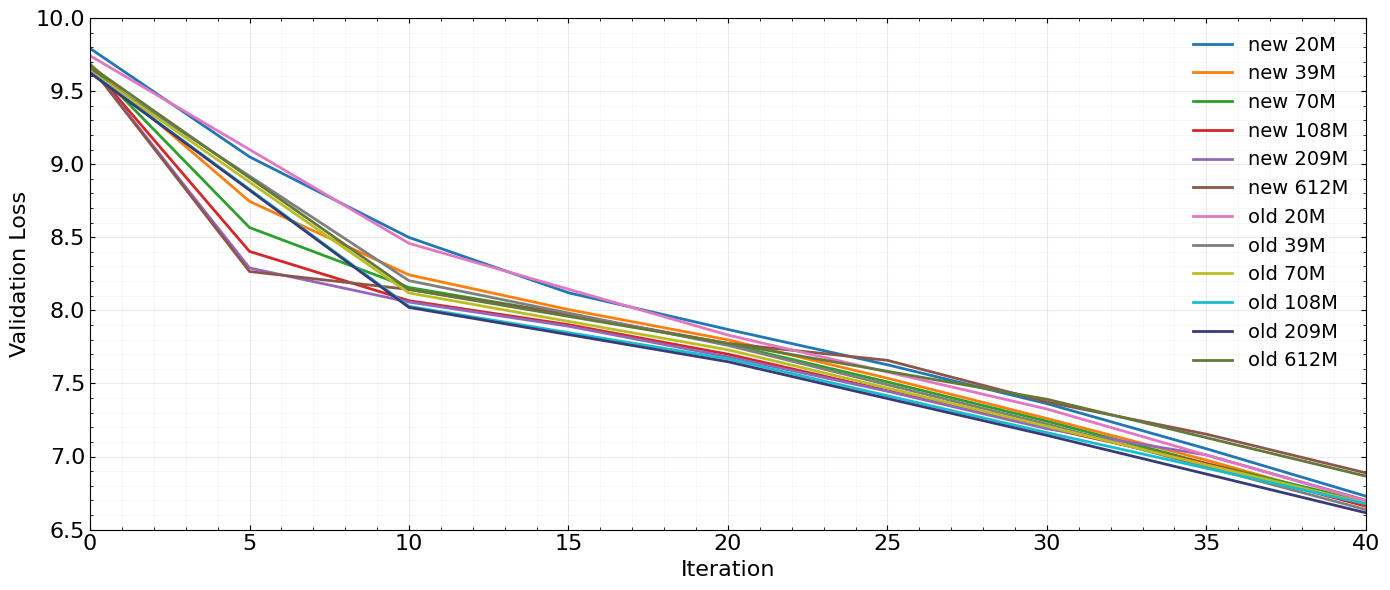

(<Figure size 1400x600 with 1 Axes>,
 <Axes: xlabel='Iteration', ylabel='Validation Loss'>)

In [36]:
model_names_and_labels = {
    'model_exp11_100k_lr1_tp1_rp2': 'new 20M',
    'model_exp11_100k_lr1_tp6_rp2': 'new 39M',
    'model_exp11_100k_lr1_tp4_rp2': 'new 70M',
    'model_exp11_100k_lr1_tp3_rp2': 'new 108M',
    'model_exp11_100k_lr1_tp2_rp2': 'new 209M',
    'model_exp11_100k_lr1_tp5_rp2': 'new 612M',
    
    'model_exp11_100k_lr1': 'old 20M',
    'model_exp11_100k_lr1_tp6': 'old 39M',
    'model_exp11_100k_lr1_tp4': 'old 70M',
    'model_exp11_100k_lr1_tp3': 'old 108M',
    'model_exp11_100k_lr1_tp2': 'old 209M',
    'model_exp11_100k_lr1_tp5': 'old 612M',
}

model_names = list(model_names_and_labels.keys())
model_labels = list(model_names_and_labels.values())
analv2.plotting_v2.plot_training_run(
    model_names, model_legend_title=model_labels,
    show_val_loss=True, use_log=False, 
    y_lim=(6.5, 10), x_lim=(0, 40), figsize=(14, 6)
)

## 100k dataset

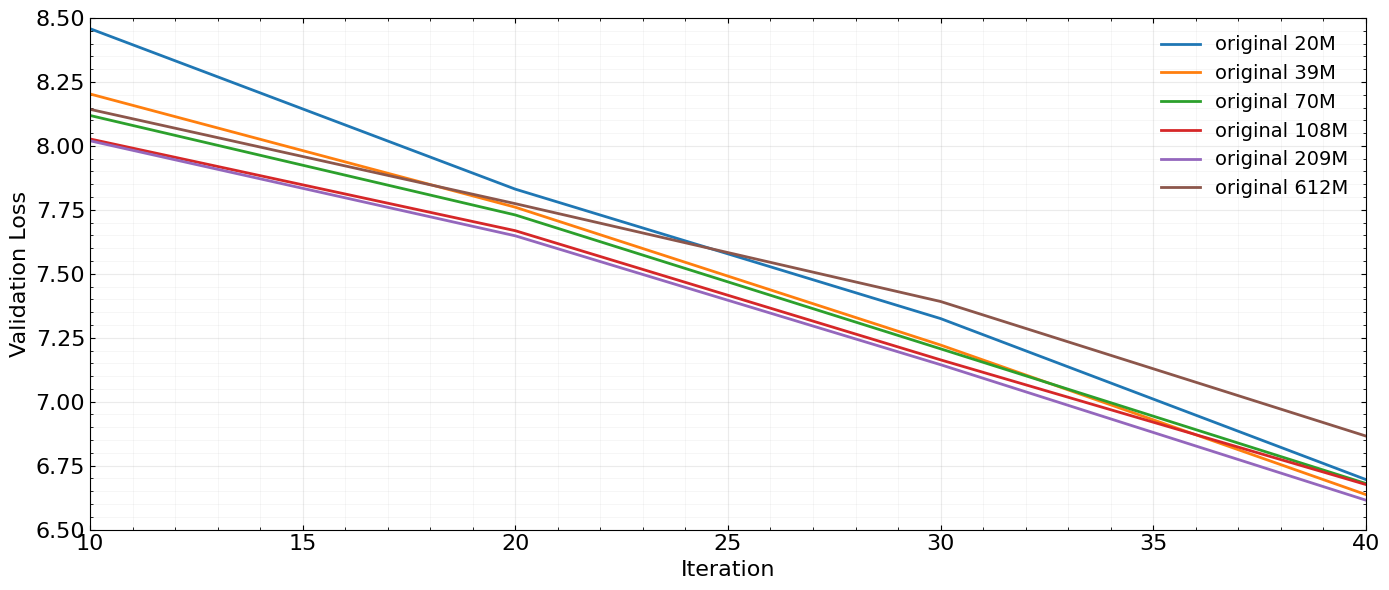

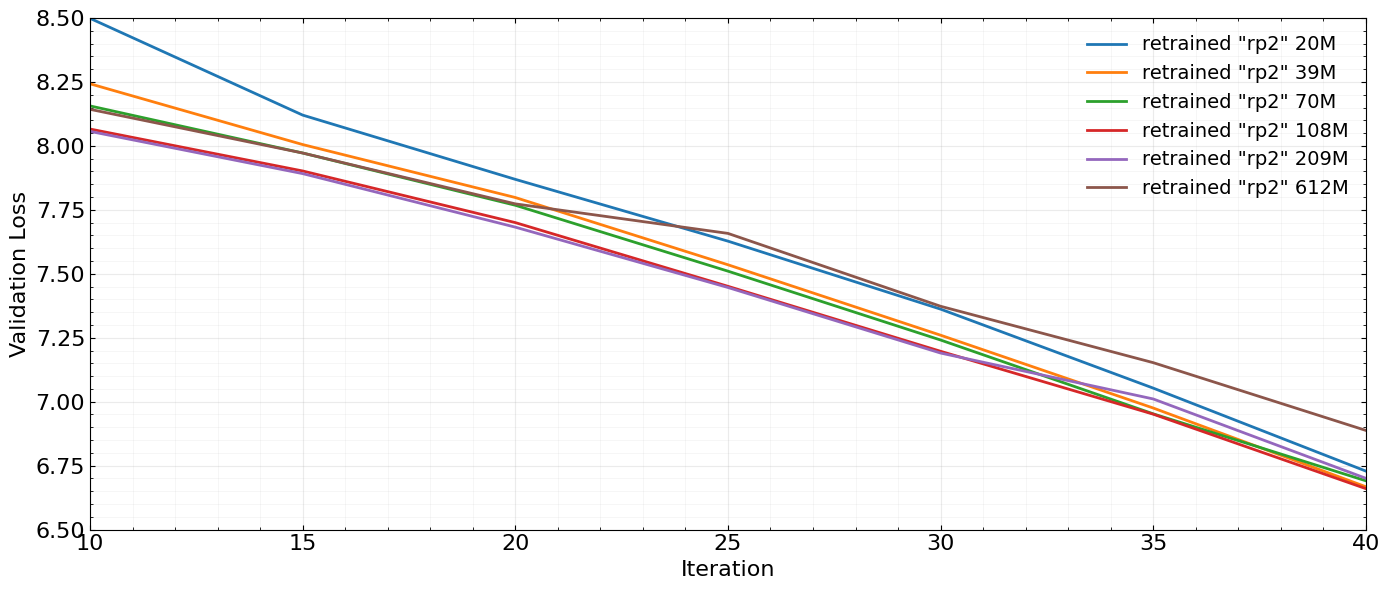

(<Figure size 1400x600 with 1 Axes>,
 <Axes: xlabel='Iteration', ylabel='Validation Loss'>)

In [37]:
model_names_and_labels = {
    'model_exp11_100k_lr1': 'original 20M',
    'model_exp11_100k_lr1_tp6': 'original 39M',
    'model_exp11_100k_lr1_tp4': 'original 70M',
    'model_exp11_100k_lr1_tp3': 'original 108M',
    'model_exp11_100k_lr1_tp2': 'original 209M',
    'model_exp11_100k_lr1_tp5': 'original 612M',
}
model_names = list(model_names_and_labels.keys())
model_labels = list(model_names_and_labels.values())
analv2.plotting_v2.plot_training_run(
    model_names, model_legend_title=model_labels,
    show_val_loss=True, show_lr_schedule=False, use_log=False, 
    y_lim=(6.5, 8.5), x_lim=(10, 40), figsize=(14, 6)
)

model_names_and_labels = {
    'model_exp11_100k_lr1_tp1_rp2': 'retrained "rp2" 20M',
    'model_exp11_100k_lr1_tp6_rp2': 'retrained "rp2" 39M',
    'model_exp11_100k_lr1_tp4_rp2': 'retrained "rp2" 70M',
    'model_exp11_100k_lr1_tp3_rp2': 'retrained "rp2" 108M',
    'model_exp11_100k_lr1_tp2_rp2': 'retrained "rp2" 209M',
    'model_exp11_100k_lr1_tp5_rp2': 'retrained "rp2" 612M',
}
model_names = list(model_names_and_labels.keys())
model_labels = list(model_names_and_labels.values())
analv2.plotting_v2.plot_training_run(
    model_names, model_legend_title=model_labels,
    show_val_loss=True, show_lr_schedule=False, use_log=False, 
    y_lim=(6.5, 8.5), x_lim=(10, 40), figsize=(14, 6)
)

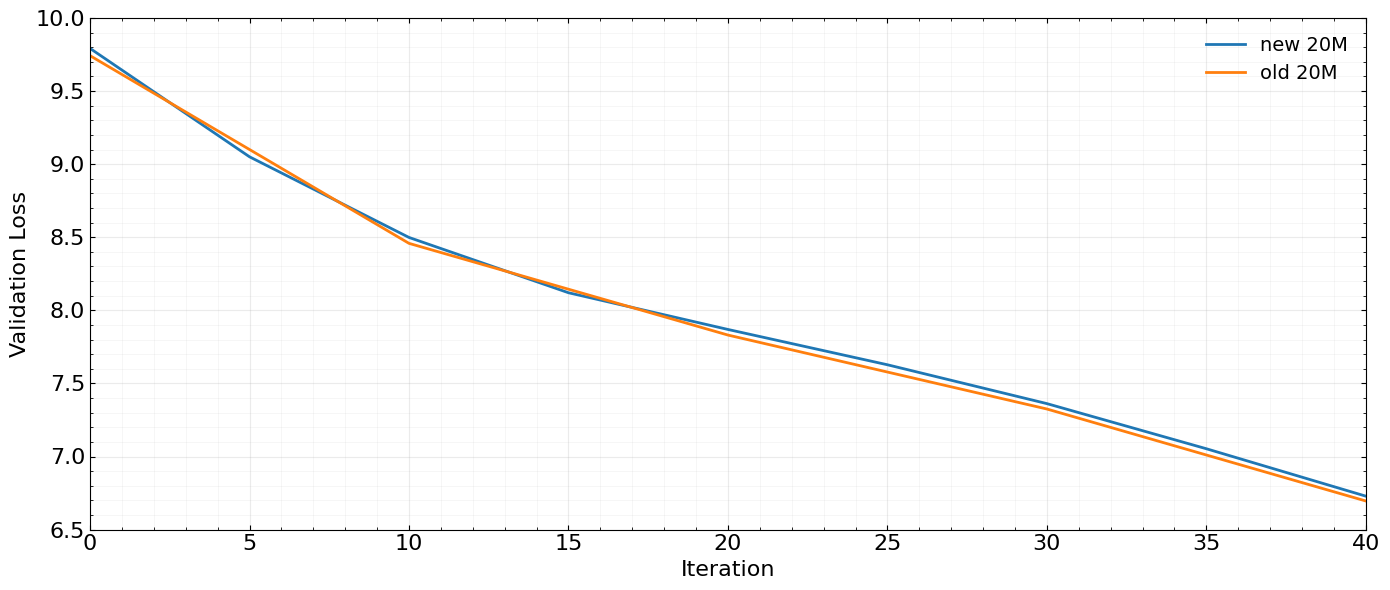

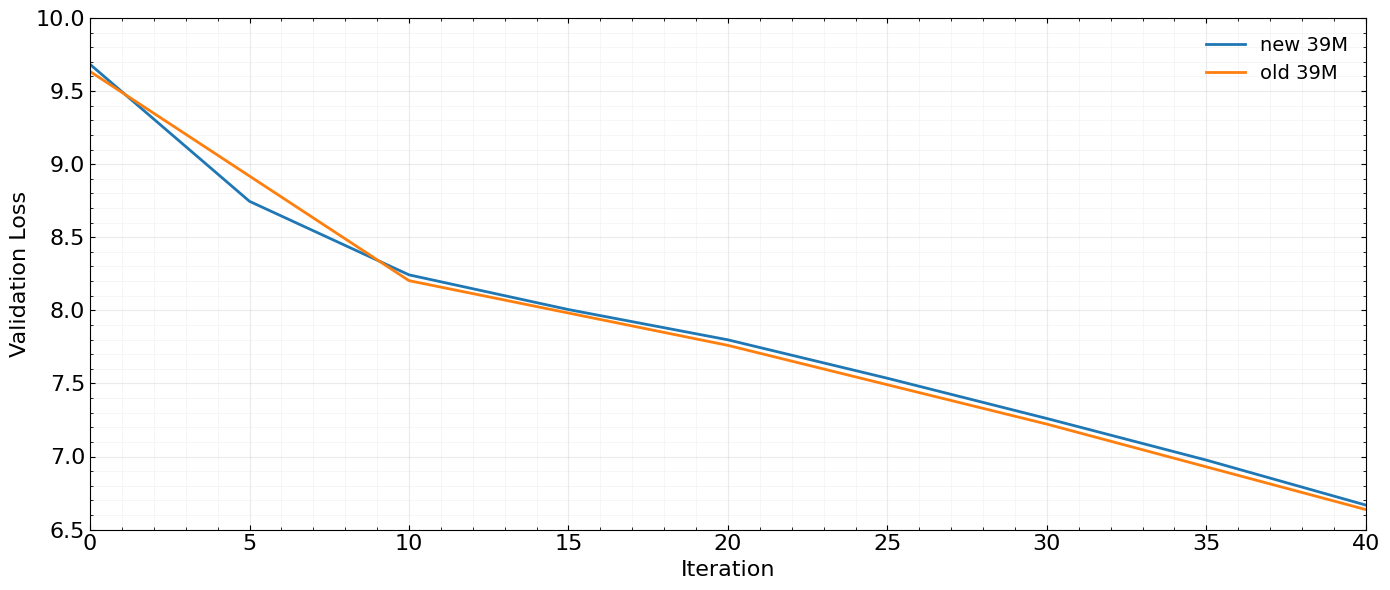

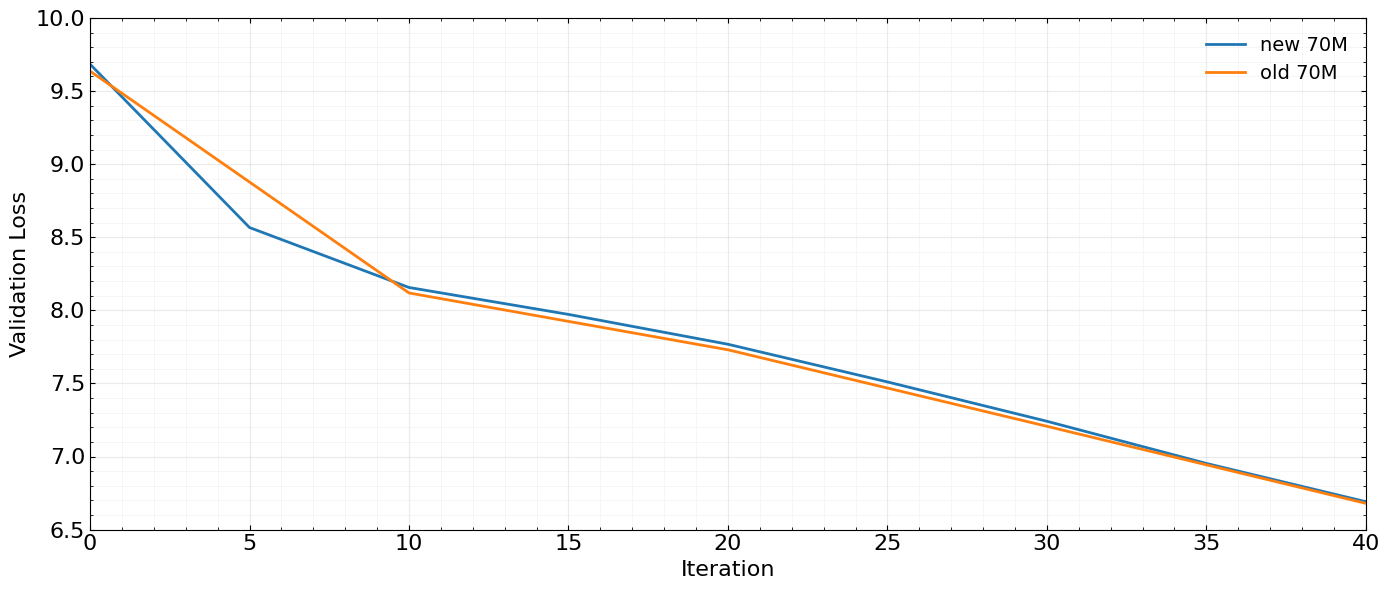

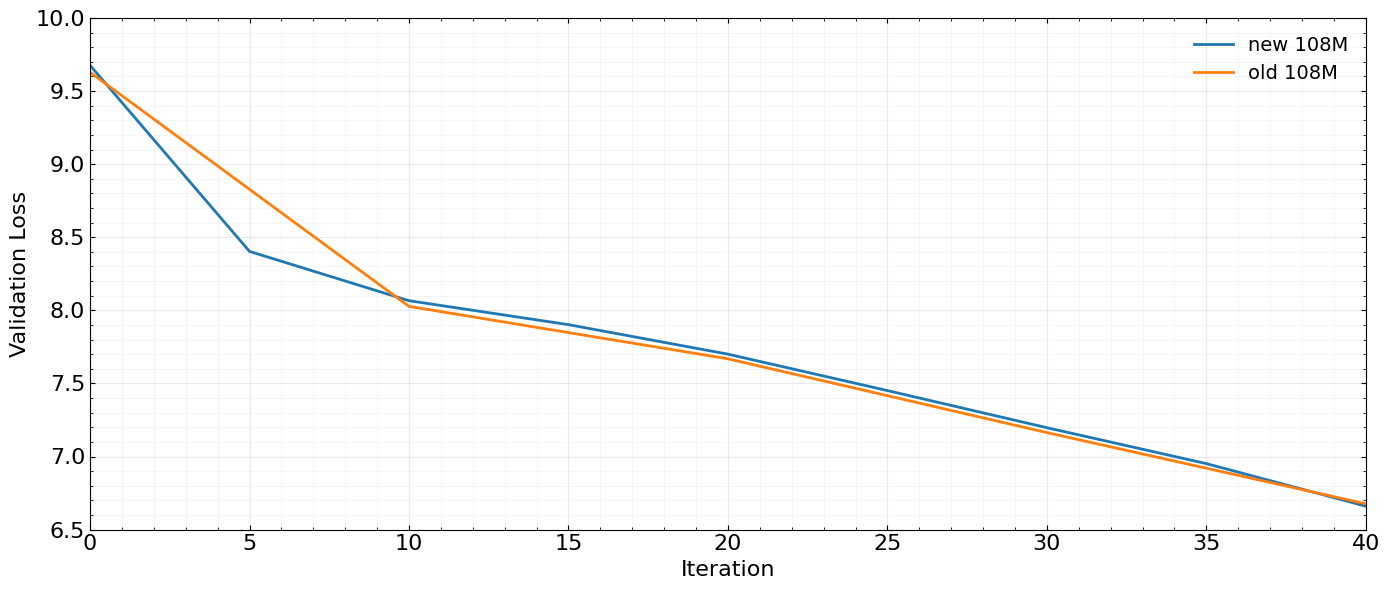

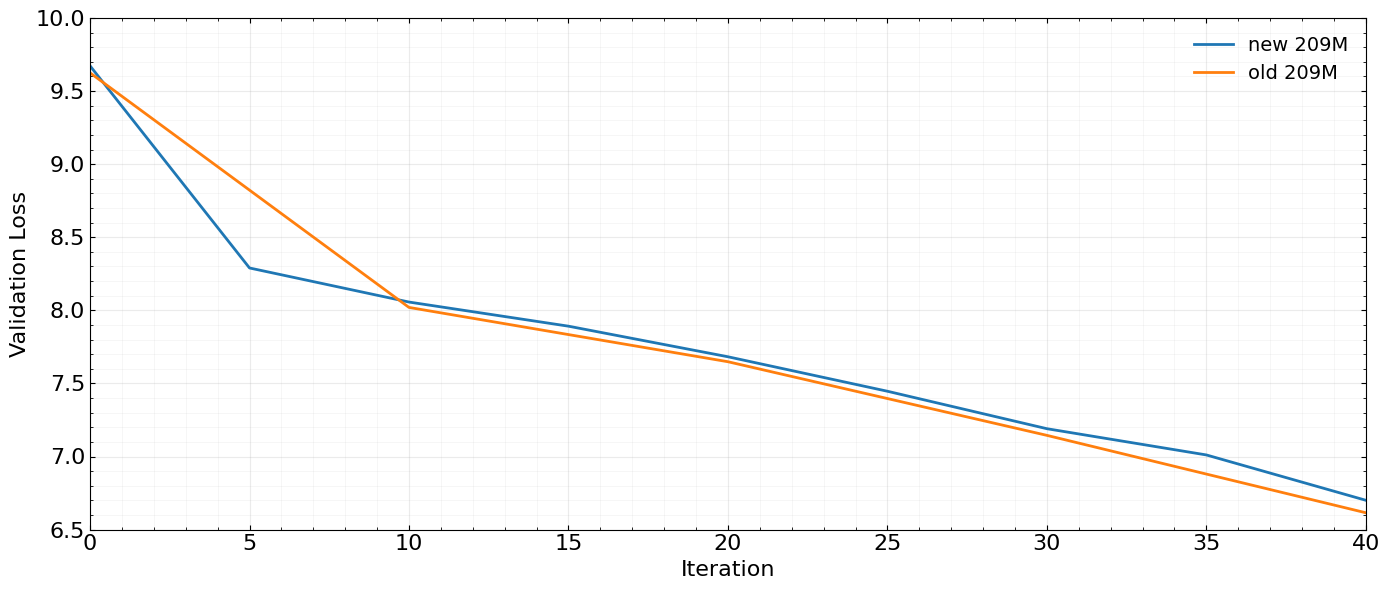

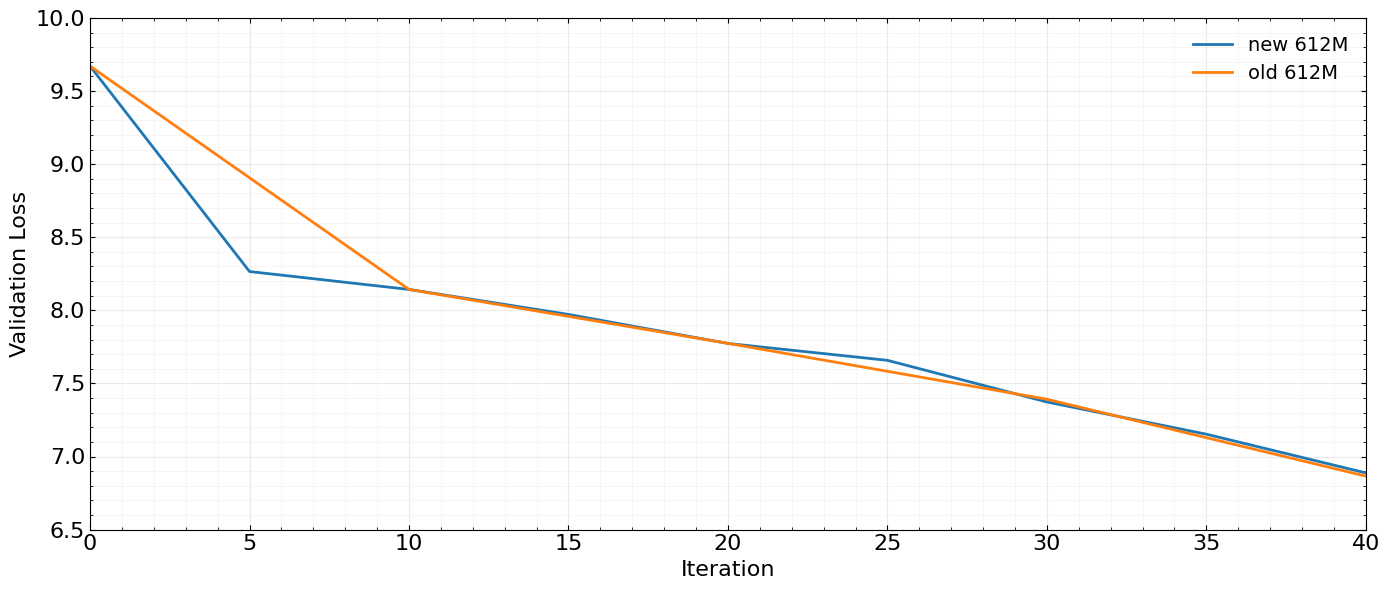

(<Figure size 1400x600 with 1 Axes>,
 <Axes: xlabel='Iteration', ylabel='Validation Loss'>)

In [38]:
model_names_and_labels = {
    'model_exp11_100k_lr1_tp1_rp2': 'new 20M',
    'model_exp11_100k_lr1': 'old 20M',
}
model_names = list(model_names_and_labels.keys())
model_labels = list(model_names_and_labels.values())
analv2.plotting_v2.plot_training_run(
    model_names, model_legend_title=model_labels,
    show_val_loss=True, use_log=False, 
    y_lim=(6.5, 10), x_lim=(0, 40), figsize=(14, 6)
)

model_names_and_labels = {
    'model_exp11_100k_lr1_tp6_rp2': 'new 39M',
    'model_exp11_100k_lr1_tp6': 'old 39M',
}
model_names = list(model_names_and_labels.keys())
model_labels = list(model_names_and_labels.values())
analv2.plotting_v2.plot_training_run(
    model_names, model_legend_title=model_labels,
    show_val_loss=True, use_log=False, 
    y_lim=(6.5, 10), x_lim=(0, 40), figsize=(14, 6)
)

model_names_and_labels = {
    'model_exp11_100k_lr1_tp4_rp2': 'new 70M',
    'model_exp11_100k_lr1_tp4': 'old 70M',
}
model_names = list(model_names_and_labels.keys())
model_labels = list(model_names_and_labels.values())
analv2.plotting_v2.plot_training_run(
    model_names, model_legend_title=model_labels,
    show_val_loss=True, use_log=False, 
    y_lim=(6.5, 10), x_lim=(0, 40), figsize=(14, 6)
)

model_names_and_labels = {
    'model_exp11_100k_lr1_tp3_rp2': 'new 108M',
    'model_exp11_100k_lr1_tp3': 'old 108M',
}
model_names = list(model_names_and_labels.keys())
model_labels = list(model_names_and_labels.values())
analv2.plotting_v2.plot_training_run(
    model_names, model_legend_title=model_labels,
    show_val_loss=True, use_log=False, 
    y_lim=(6.5, 10), x_lim=(0, 40), figsize=(14, 6)
)

model_names_and_labels = {
    'model_exp11_100k_lr1_tp2_rp2': 'new 209M',
    'model_exp11_100k_lr1_tp2': 'old 209M',
}
model_names = list(model_names_and_labels.keys())
model_labels = list(model_names_and_labels.values())
analv2.plotting_v2.plot_training_run(
    model_names, model_legend_title=model_labels,
    show_val_loss=True, use_log=False, 
    y_lim=(6.5, 10), x_lim=(0, 40), figsize=(14, 6)
)

model_names_and_labels = {
    'model_exp11_100k_lr1_tp5_rp2': 'new 612M',
    'model_exp11_100k_lr1_tp5': 'old 612M',
}
model_names = list(model_names_and_labels.keys())
model_labels = list(model_names_and_labels.values())
analv2.plotting_v2.plot_training_run(
    model_names, model_legend_title=model_labels,
    show_val_loss=True, use_log=False, 
    y_lim=(6.5, 10), x_lim=(0, 40), figsize=(14, 6)
)

## 500k dataset

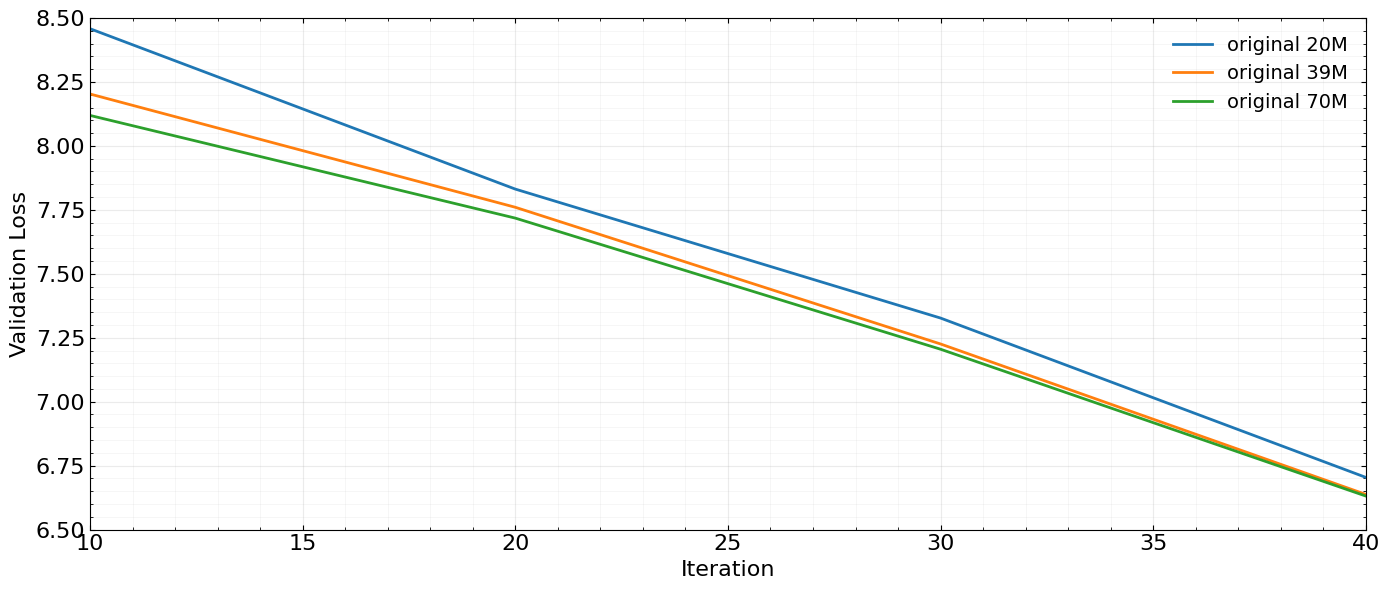

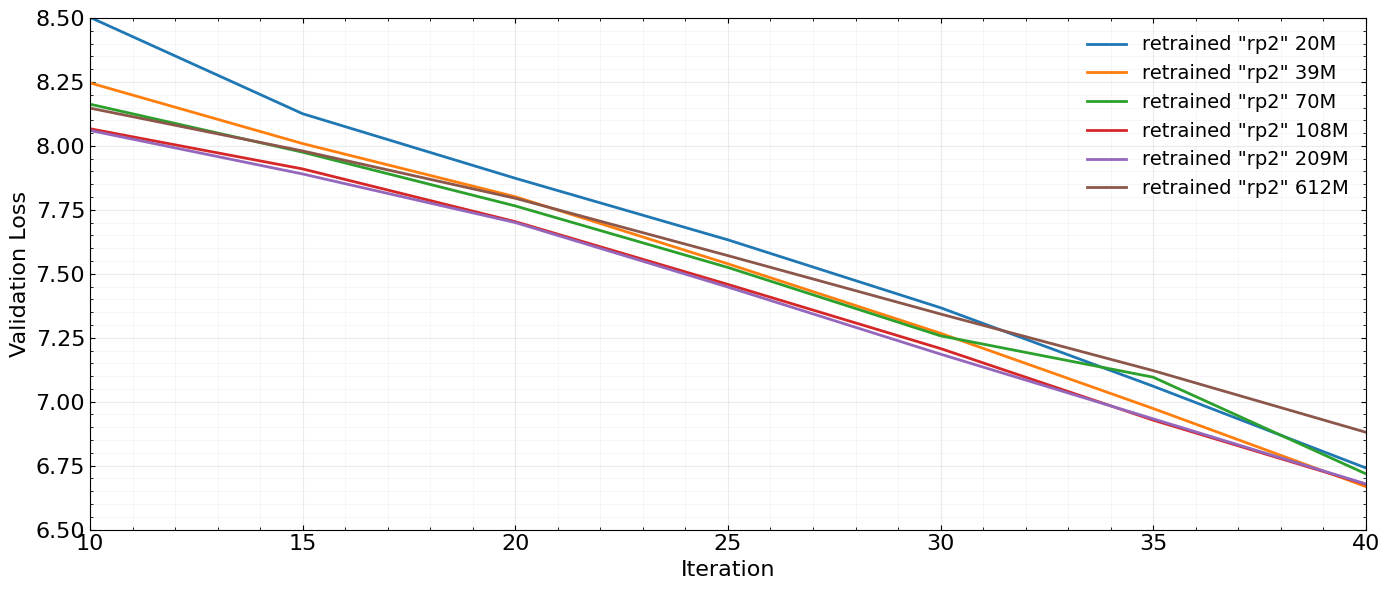

(<Figure size 1400x600 with 1 Axes>,
 <Axes: xlabel='Iteration', ylabel='Validation Loss'>)

In [39]:
model_names_and_labels = {
    'model_exp11_500k_lr1': 'original 20M',
    'model_exp11_500k_lr1_tp6': 'original 39M',
    'model_exp11_500k_lr1_tp4': 'original 70M',
    # 'model_exp11_500k_lr1_tp3': 'original 108M',
    # 'model_exp11_500k_lr1_tp2': 'original 209M',
    # 'model_exp11_500k_lr1_tp5': 'original 612M',
}
model_names = list(model_names_and_labels.keys())
model_labels = list(model_names_and_labels.values())
analv2.plotting_v2.plot_training_run(
    model_names, model_legend_title=model_labels,
    show_val_loss=True, use_log=False, 
    y_lim=(6.5, 8.5), x_lim=(10, 40), figsize=(14, 6)
)

model_names_and_labels = {
    'model_exp11_500k_lr1_tp1_rp2': 'retrained "rp2" 20M',
    'model_exp11_500k_lr1_tp6_rp2': 'retrained "rp2" 39M',
    'model_exp11_500k_lr1_tp4_rp2': 'retrained "rp2" 70M',
    'model_exp11_500k_lr1_tp3_rp2': 'retrained "rp2" 108M',
    'model_exp11_500k_lr1_tp2_rp2': 'retrained "rp2" 209M',
    'model_exp11_500k_lr1_tp5_rp2': 'retrained "rp2" 612M',
}
model_names = list(model_names_and_labels.keys())
model_labels = list(model_names_and_labels.values())
analv2.plotting_v2.plot_training_run(
    model_names, model_legend_title=model_labels,
    show_val_loss=True, use_log=False, 
    y_lim=(6.5, 8.5), x_lim=(10, 40), figsize=(14, 6)
)

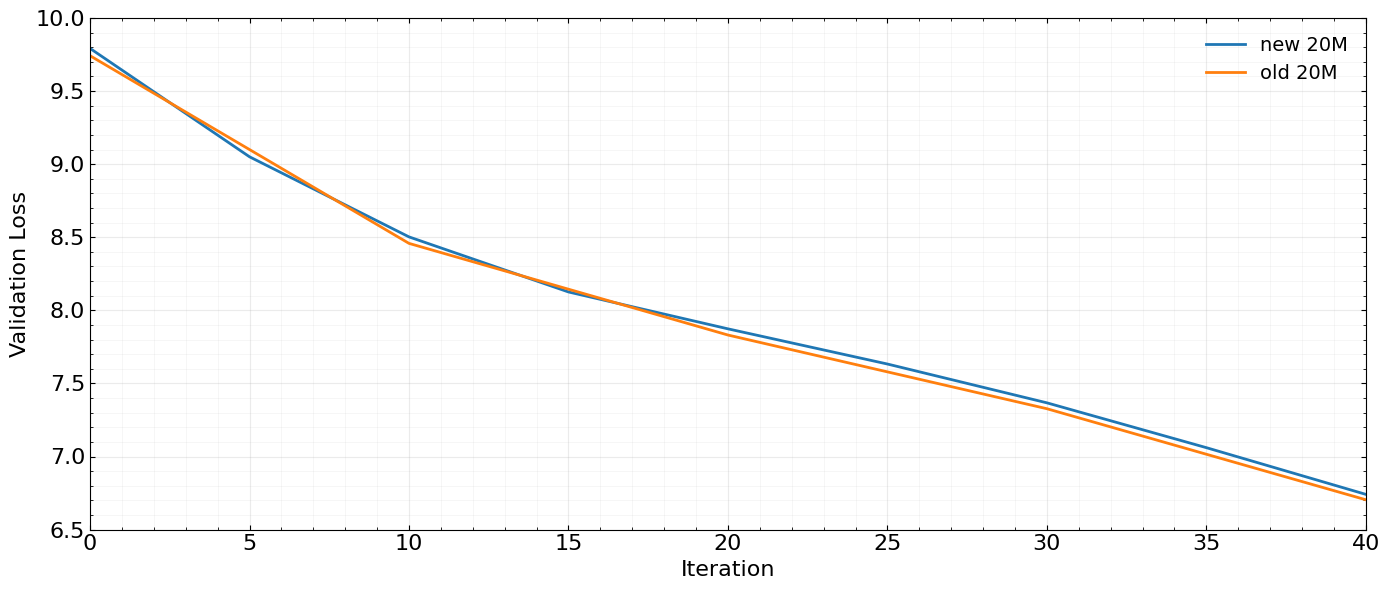

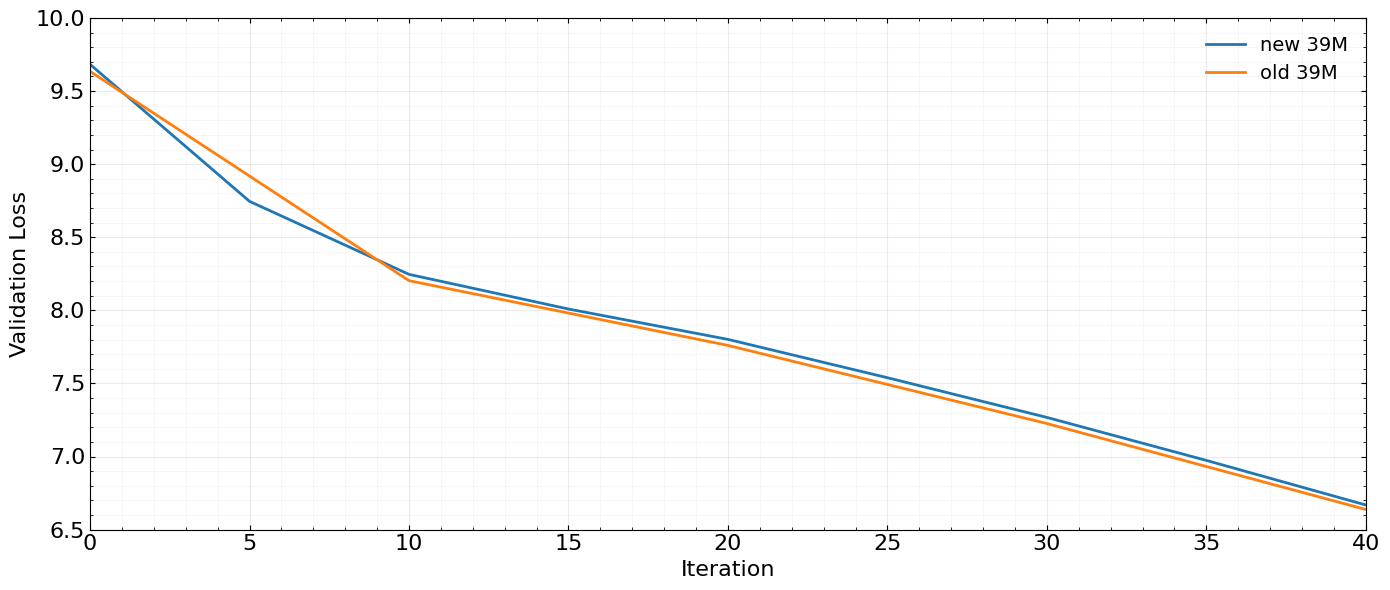

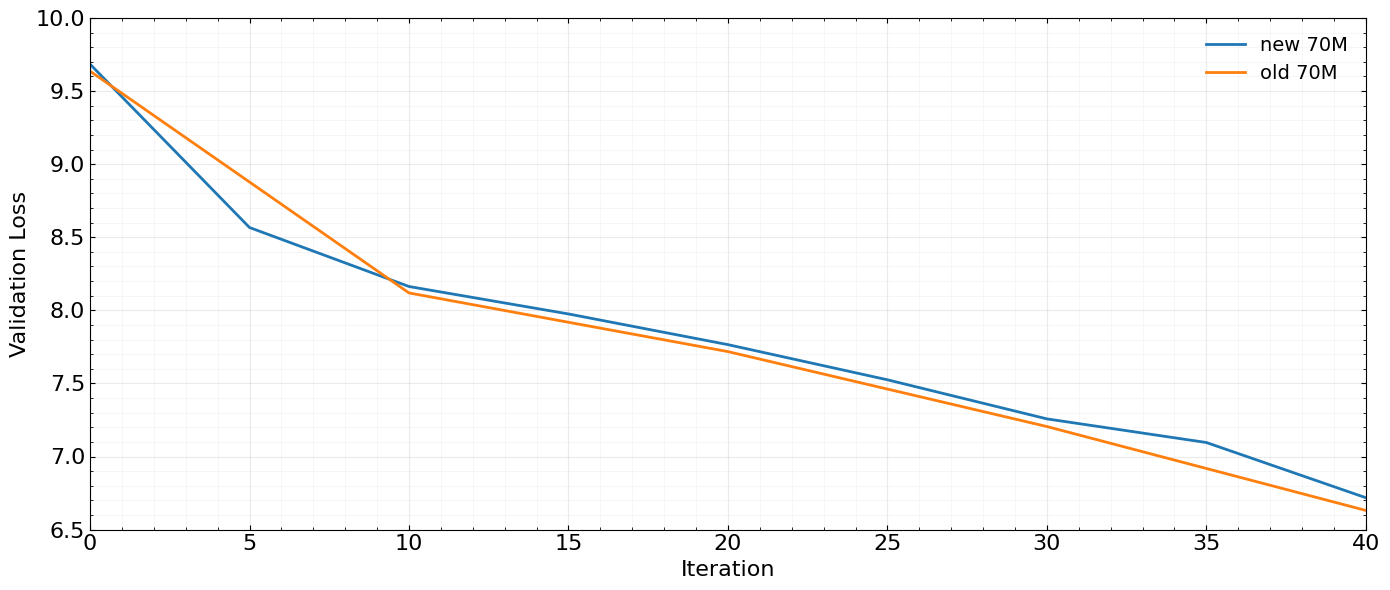

(<Figure size 1400x600 with 1 Axes>,
 <Axes: xlabel='Iteration', ylabel='Validation Loss'>)

In [40]:
model_names_and_labels = {
    'model_exp11_500k_lr1_tp1_rp2': 'new 20M',
    'model_exp11_500k_lr1': 'old 20M',
}
model_names = list(model_names_and_labels.keys())
model_labels = list(model_names_and_labels.values())
analv2.plotting_v2.plot_training_run(
    model_names, model_legend_title=model_labels,
    show_val_loss=True, use_log=False, 
    y_lim=(6.5, 10), x_lim=(0, 40), figsize=(14, 6)
)

model_names_and_labels = {
    'model_exp11_500k_lr1_tp6_rp2': 'new 39M',
    'model_exp11_500k_lr1_tp6': 'old 39M',
}
model_names = list(model_names_and_labels.keys())
model_labels = list(model_names_and_labels.values())
analv2.plotting_v2.plot_training_run(
    model_names, model_legend_title=model_labels,
    show_val_loss=True, use_log=False, 
    y_lim=(6.5, 10), x_lim=(0, 40), figsize=(14, 6)
)

model_names_and_labels = {
    'model_exp11_500k_lr1_tp4_rp2': 'new 70M',
    'model_exp11_500k_lr1_tp4': 'old 70M',
}
model_names = list(model_names_and_labels.keys())
model_labels = list(model_names_and_labels.values())
analv2.plotting_v2.plot_training_run(
    model_names, model_legend_title=model_labels,
    show_val_loss=True, use_log=False, 
    y_lim=(6.5, 10), x_lim=(0, 40), figsize=(14, 6)
)

# model_names_and_labels = {
#     'model_exp11_500k_lr1_tp3_rp2': 'new 108M',
#     'model_exp11_500k_lr1_tp3': 'old 108M',
# }
# model_names = list(model_names_and_labels.keys())
# model_labels = list(model_names_and_labels.values())
# analv2.plotting_v2.plot_training_run(
#     model_names, model_legend_title=model_labels,
#     show_val_loss=True, use_log=False, 
#     y_lim=(6.5, 10), x_lim=(0, 40), figsize=(14, 6)
# )

# model_names_and_labels = {
#     'model_exp11_500k_lr1_tp2_rp2': 'new 209M',
#     'model_exp11_500k_lr1_tp2': 'old 209M',
# }
# model_names = list(model_names_and_labels.keys())
# model_labels = list(model_names_and_labels.values())
# analv2.plotting_v2.plot_training_run(
#     model_names, model_legend_title=model_labels,
#     show_val_loss=True, use_log=False, 
#     y_lim=(6.5, 10), x_lim=(0, 40), figsize=(14, 6)
# )

# model_names_and_labels = {
#     'model_exp11_500k_lr1_tp5_rp2': 'new 612M',
#     'model_exp11_500k_lr1_tp5': 'old 612M',
# }
# model_names = list(model_names_and_labels.keys())
# model_labels = list(model_names_and_labels.values())
# analv2.plotting_v2.plot_training_run(
#     model_names, model_legend_title=model_labels,
#     show_val_loss=True, use_log=False, 
#     y_lim=(6.5, 10), x_lim=(0, 40), figsize=(14, 6)
# )